# VAL-03: Bootstrap 군집 안정성 검증

**선행 조건**: `val_02_kmeans.ipynb` 실행 완료
- `notebook/data/df_feat_clean.csv`
- `notebook/data/cluster_assignments.csv`

**목적**: K=6 군집이 데이터 서브셋에서도 안정적으로 재현되는지 확인  
**지표**: Adjusted Rand Index (ARI) — 1.0에 가까울수록 안정적

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings, platform
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score

if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
    try:
        fe = fm.FontEntry(fname=font_path, name='NanumGothic')
        fm.fontManager.ttflist.insert(0, fe)
        plt.rcParams['font.family'] = 'NanumGothic'
    except:
        pass
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120
print('로딩 완료')

로딩 완료


---
## 1. 저장된 데이터 로딩

In [2]:
import os
assert os.path.exists('data/df_feat_clean.csv'),       '❌ val_01_data.ipynb 먼저 실행'
assert os.path.exists('data/cluster_assignments.csv'), '❌ val_02_kmeans.ipynb 먼저 실행'

FEATURE_COLS = [
    'total_resident_population', 'total_households', 'gas_supply_ratio',
    'home_ratio', 'public_ratio', 'service_ratio', 'industry_ratio'
]

df_feat    = pd.read_csv('data/df_feat_clean.csv',       encoding='utf-8-sig')
cluster_df = pd.read_csv('data/cluster_assignments.csv', encoding='utf-8-sig')

scaler = StandardScaler()
X = scaler.fit_transform(df_feat[FEATURE_COLS])

labels_target = cluster_df['cluster'].values
K_TARGET = int(cluster_df['cluster'].nunique())

print(f'df_feat: {df_feat.shape}')
print(f'X shape: {X.shape}')
print(f'K_TARGET: {K_TARGET}')
print(f'cluster unique: {sorted(np.unique(labels_target))}')

df_feat: (150, 9)
X shape: (150, 7)
K_TARGET: 6
cluster unique: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


---
## 2. Bootstrap ARI

In [3]:
N_BOOTSTRAP  = 100
SAMPLE_RATIO = 0.8
ari_scores   = []
np.random.seed(42)

for i in range(N_BOOTSTRAP):
    idx = np.random.choice(len(X), size=int(len(X) * SAMPLE_RATIO), replace=False)
    km_boot = KMeans(n_clusters=K_TARGET, random_state=np.random.randint(10000), n_init=5)
    labels_boot = km_boot.fit_predict(X[idx])
    ari = adjusted_rand_score(labels_target[idx], labels_boot)
    ari_scores.append(ari)
    if (i + 1) % 20 == 0:
        print(f'  {i+1}/{N_BOOTSTRAP} 완료  현재 평균 ARI: {np.mean(ari_scores):.4f}')

ari_mean = np.mean(ari_scores)
ari_std  = np.std(ari_scores)
ari_min  = np.min(ari_scores)
ari_max  = np.max(ari_scores)

print()
print(f'Bootstrap ARI (K={K_TARGET}, n={N_BOOTSTRAP}, sample={int(SAMPLE_RATIO*100)}%)')
print(f'  평균: {ari_mean:.4f}')
print(f'  표준편차: {ari_std:.4f}')
print(f'  범위: [{ari_min:.4f}, {ari_max:.4f}]')

Exception in thread Thread-3 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\vacke\anaconda3\Lib\threading.py", line 1043, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "c:\Users\vacke\anaconda3\Lib\site-packages\ipykernel\ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
    ~~~~~~~~~~~~~~~~~~~~~^^^^^^
  File "c:\Users\vacke\anaconda3\Lib\threading.py", line 994, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\vacke\anaconda3\Lib\subprocess.py", line 1615, in _readerthread
    buffer.append(fh.read())
                  ~~~~~~~^^
  File "<frozen codecs>", line 325, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xba in position 24: invalid start byte
  File "c:\Users\vacke\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 262, in _count_physical_cores
    cpu_info = cpu_info.stdout.splitlines()
               ^^^^^^^^^^^^^^^^^

  20/100 완료  현재 평균 ARI: 0.6716
  40/100 완료  현재 평균 ARI: 0.6593
  60/100 완료  현재 평균 ARI: 0.6608
  80/100 완료  현재 평균 ARI: 0.6661
  100/100 완료  현재 평균 ARI: 0.6737

Bootstrap ARI (K=6, n=100, sample=80%)
  평균: 0.6737
  표준편차: 0.1667
  범위: [0.3912, 1.0000]


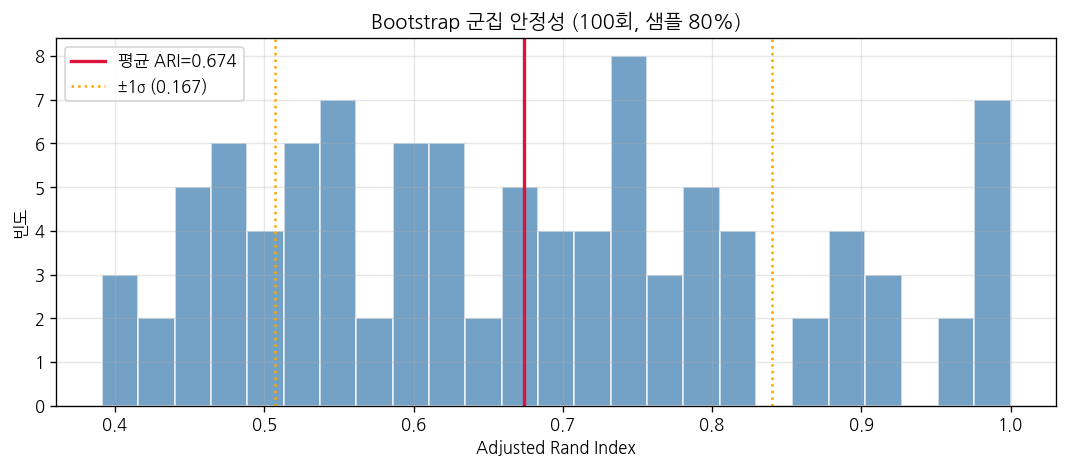


판정: ✅ 안정적 (ARI ≥ 0.6)


In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(ari_scores, bins=25, color='steelblue', alpha=0.75, edgecolor='white')
ax.axvline(ari_mean, color='crimson', linewidth=2, label=f'평균 ARI={ari_mean:.3f}')
ax.axvline(ari_mean - ari_std, color='orange', linestyle=':', linewidth=1.5)
ax.axvline(ari_mean + ari_std, color='orange', linestyle=':', linewidth=1.5,
           label=f'±1σ ({ari_std:.3f})')
ax.set_xlabel('Adjusted Rand Index'); ax.set_ylabel('빈도')
ax.set_title(f'Bootstrap 군집 안정성 ({N_BOOTSTRAP}회, 샘플 {int(SAMPLE_RATIO*100)}%)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 판정
print()
if ari_mean >= 0.8:
    grade = '✅ 매우 안정적 (ARI ≥ 0.8)'
elif ari_mean >= 0.6:
    grade = '✅ 안정적 (ARI ≥ 0.6)'
elif ari_mean >= 0.4:
    grade = '⚠️ 보통 (ARI ≥ 0.4) — 해석 시 주의 필요'
else:
    grade = '❌ 불안정 (ARI < 0.4) — K=6 재검토 권장'
print(f'판정: {grade}')

---
## 3. Self-Consistency 확인

> `random_state`만 다른 10번 실행에서 군집 할당이 얼마나 일치하는지 확인  
> (레이블 번호가 달라도 동일한 구조인지 ARI로 측정)

In [5]:
N_RUNS = 10
all_labels = []

for seed in range(N_RUNS):
    km = KMeans(n_clusters=K_TARGET, random_state=seed * 7, n_init=10)
    all_labels.append(km.fit_predict(X))

ari_runs = [adjusted_rand_score(labels_target, lab) for lab in all_labels]

print(f'기준 레이블(val_02 K={K_TARGET}, random_state=42)과의 ARI:')
for i, ari in enumerate(ari_runs):
    bar = '█' * int(ari * 20)
    print(f'  run{i:02d}: {ari:.4f}  {bar}')
print()
print(f'평균 ARI: {np.mean(ari_runs):.4f}  최소: {np.min(ari_runs):.4f}')
print()
if np.min(ari_runs) >= 0.9:
    print(f'→ ✅ K={K_TARGET} 군집 구조가 random_state 무관하게 안정적')
elif np.min(ari_runs) >= 0.6:
    print('→ ⚠️ 대체로 비슷하나 일부 경계 자치구가 실행마다 달라질 수 있음')
else:
    print(f'→ ❌ random_state에 따라 결과가 크게 달라짐 — n_init 증가 또는 K 재검토 필요')

기준 레이블(val_02 K=6, random_state=42)과의 ARI:
  run00: 0.8114  ████████████████
  run01: 0.7289  ██████████████
  run02: 1.0000  ████████████████████
  run03: 0.8917  █████████████████
  run04: 1.0000  ████████████████████
  run05: 0.9462  ██████████████████
  run06: 1.0000  ████████████████████
  run07: 0.8234  ████████████████
  run08: 0.9350  ██████████████████
  run09: 1.0000  ████████████████████

평균 ARI: 0.9137  최소: 0.7289

→ ⚠️ 대체로 비슷하나 일부 경계 자치구가 실행마다 달라질 수 있음
